In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
import sys
import os

# Add parent directory to Python path
sys.path.insert(0, os.path.abspath('..'))

# Import FEM modules
from fem.core import Node, Material
from fem.sections import Membrane
from fem.elements import CST, LST, Quad4, Quad9
from fem.utils import get_line_load_global_vector

from fem.utils import add_element_data_view, add_node_data_view, compute_nodal_average
from fem.utils.functions import build_nodes_from_gmsh, create_elements_from_gmsh, build_load_vector

# Import standard libraries
import numpy as np
np.set_printoptions(suppress=True, precision=6, linewidth=400)
import matplotlib.pyplot as plt
import gmsh
import math

In [3]:
# General model parameters
L = 5000 
number_floors = 10
floor_height = 3500
H = floor_height * number_floors
B = 350

lc = 500

output_path = os.getcwd()
mesh_name = 'sw_00'
output_file = os.path.join(output_path, mesh_name + '.msh')
if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)
# Create points for each floor level
# Bottom points
points_left = [gmsh.model.geo.addPoint(0, 0, 0, lc)]  # p1
points_center = [gmsh.model.geo.addPoint(L/2, 0, 0, lc)]  # p5
points_right = [gmsh.model.geo.addPoint(L, 0, 0, lc)]  # p2
# Create points at each floor level
for i in range(1, number_floors + 1):
    y = i * floor_height
    points_left.append(gmsh.model.geo.addPoint(0, y, 0, lc))
    points_center.append(gmsh.model.geo.addPoint(L/2, y, 0, lc))
    points_right.append(gmsh.model.geo.addPoint(L, y, 0, lc))
# Create horizontal and vertical lines for each floor
surfaces_left = []
surfaces_right = []
bottom_lines = []  # Store bottom lines for supports
floor_top_lines = []  # Store top lines of each floor for distributed loads

for i in range(number_floors):
    # Horizontal lines (bottom and top of each floor)
    h_bottom_left = gmsh.model.geo.addLine(points_left[i], points_center[i])
    h_bottom_right = gmsh.model.geo.addLine(points_center[i], points_right[i])
    h_top_left = gmsh.model.geo.addLine(points_left[i+1], points_center[i+1])
    h_top_right = gmsh.model.geo.addLine(points_center[i+1], points_right[i+1])
    
    # Save bottom lines only for first floor (i==0)
    if i == 0:
        bottom_lines.extend([h_bottom_left, h_bottom_right])
    
    # Save top lines of each floor for distributed loads
    floor_top_lines.extend([h_top_left, h_top_right])
    
    # Vertical lines
    v_left = gmsh.model.geo.addLine(points_left[i], points_left[i+1])
    v_center = gmsh.model.geo.addLine(points_center[i], points_center[i+1])
    v_right = gmsh.model.geo.addLine(points_right[i], points_right[i+1])
    
    # Create surfaces for left half
    curve_loop_left = gmsh.model.geo.addCurveLoop([h_bottom_left, v_center, -h_top_left, -v_left])
    surface_left = gmsh.model.geo.addPlaneSurface([curve_loop_left])
    surfaces_left.append(surface_left)
    
    # Create surfaces for right half
    curve_loop_right = gmsh.model.geo.addCurveLoop([h_bottom_right, v_right, -h_top_right, -v_center])
    surface_right = gmsh.model.geo.addPlaneSurface([curve_loop_right])
    surfaces_right.append(surface_right)
# Synchronize the model
gmsh.model.geo.synchronize()
# Create physical groups for all surfaces
all_surfaces = surfaces_left + surfaces_right
gmsh.model.addPhysicalGroup(2, all_surfaces, 201)
gmsh.model.setPhysicalName(2, 201, "Wall")
# Supports at entire bottom line (y=0) - NOW AS LINES
gmsh.model.addPhysicalGroup(1, bottom_lines, 101)
gmsh.model.setPhysicalName(1, 101, "Support_base")
# LOADS SECTION
# Pload_lateral at top left corner (x=0, y=H)
gmsh.model.addPhysicalGroup(0, [points_left[-1]], 301)
gmsh.model.setPhysicalName(0, 301, "Pload_lateral")
# Distributed vertical loads on top lines of each floor
gmsh.model.addPhysicalGroup(1, floor_top_lines, 302)
gmsh.model.setPhysicalName(1, 302, "Pload_vertical_distributed")
# Synchronize the model
gmsh.model.geo.synchronize()
def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 2)
    
# all_quads()
gmsh.option.setNumber("Mesh.ElementOrder", 2)

In [5]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 10%] Meshing curve 4 (Line)
Info    : [ 10%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 10%] Meshing curve 7 (Line)
Info    : [ 20%] Meshing curve 8 (Line)
Info    : [ 20%] Meshing curve 9 (Line)
Info    : [ 20%] Meshing curve 10 (Line)
Info    : [ 20%] Meshing curve 11 (Line)
Info    : [ 20%] Meshing curve 12 (Line)
Info    : [ 20%] Meshing curve 13 (Line)
Info    : [ 20%] Meshing curve 14 (Line)
Info    : [ 30%] Meshing curve 15 (Line)
Info    : [ 30%] Meshing curve 16 (Line)
Info    : [ 30%] Meshing curve 17 (Line)
Info    : [ 30%] Meshing curve 18 (Line)
Info    : [ 30%] Meshing curve 19 (Line)
Info    : [ 30%] Meshing curve 20 (Line)
Info    : [ 30%] Meshing curve 21 (Line)
Info    : [ 40%] Meshing curve 22 (Line)
Info    : [ 40%] Meshing curve 23 (Line)
Info    : [ 40%] Meshing curve 24 (Line)
I

Fontconfig warning: using without calling FcInit()


Info    : Writing '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'...
Info    : Done writing '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'


In [6]:
# Define material
fc_21 = Material(name='fc_21',
                 E=21300,
                 nu=0.20,
                 rho=0)

# Define membrane section
ConcreteWall = Membrane(name='ConcreteWall',
                        thickness=B,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteWall}

# Define distributed load magnitude  {physical_id: [x load, y load]}
Pload_vertical = 411879.31/5000
Pload_lateral = 98066.5

load_dictionary = {
    302: {'value': Pload_vertical, 'direction': '-y'},   
    301: {'value': Pload_lateral,  'direction': 'x'},  
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       }

# Define self-weight (not used)
self_weight = [0, 0]

In [7]:
node_map, nodes = build_nodes_from_gmsh(
    output_file,
    restrain_dictionary=restrain_dictionary,
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'...
Info    : 123 entities
Info    : 3787 nodes
Info    : 1843 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'


In [8]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

elements = create_elements_from_gmsh(
    output_file=output_file,
    node_map=node_map,
    section_dictionary=section_dictionary,
    element_class_map=element_map
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'...
Info    : 123 entities
Info    : 3787 nodes
Info    : 1843 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'


In [9]:
def plot_mesh(figsize=(25, 25),
              nodes=None, 
              elements=None,                
              show_node_labels=True, 
              show_element_labels=True):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot nodes if provided
    if nodes is not None:
        for node in nodes:
            node.plotGeometry(ax=ax, text=show_node_labels)
    # Plot elements if provided
    if elements is not None:
        for element in elements:
            element.plotGeometry(ax=ax)
            if show_element_labels:
                x, y = element.get_centroid()
                ax.text(x, y, f'{element.element_tag}', color='r', ha='center', fontsize=8)
    # Maintain 1:1 aspect ratio
    ax.set_aspect('equal')
    plt.show()

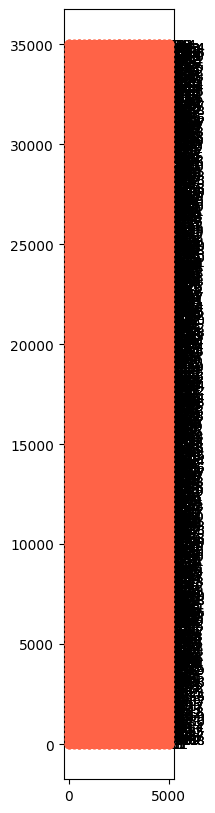

In [10]:
# Plot
plot_mesh(figsize=(10, 10) , 
          nodes=nodes,
            elements=elements, 
            show_node_labels=True, 
            show_element_labels=False)

In [11]:
# Setup system parameters
nodeList = nodes
elementList = elements

# Get total number of nodes and elements
nNodes = len(nodeList)
nElements = len(elementList)

# Define degrees of freedom per node (x, y displacements)
globalParameters = {'nDoF': 2}

# Calculate total system degrees of freedom
system_nDof = 2 * nNodes

In [12]:
F_load = build_load_vector(
    output_file=output_file,
    node_map=node_map,
    load_dictionary=load_dictionary,
    system_nDof=system_nDof
)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'...
Info    : 123 entities
Info    : 3787 nodes
Info    : 1843 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'


In [13]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Global stiffness matrix (sparse)
K = lil_matrix((system_nDof, system_nDof))
for element in elementList:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = np.zeros(system_nDof)
for node in nodeList:
    F[node.idx] += node.nodalLoad
F += F_load

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in nodeList])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]
Ff  = F[free_dofs]
Fr  = F[restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, Ff - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr      = Krf @ uf + Krr @ ur
R       = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [14]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [15]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [5000.    0.]:  ux=+0.000000  uy=+0.000000
Node 897 at [1009.888865  421.509586]:  ux=+0.002264  uy=+0.005268


In [16]:
# Reactions per node
for node in nodeList:
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' *50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=-10093.446737  Ry=-45278.521799
Node 2:  Rx=+505.937263  Ry=+66585.424855
Node 3:  Rx=-35629.942727  Ry=+148619.213623
Node 34:  Rx=+1005.661840  Ry=-45933.429577
Node 35:  Rx=+3939.491354  Ry=-16163.785873
Node 36:  Rx=+3880.788379  Ry=+13035.320965
Node 37:  Rx=+2330.606868  Ry=+40621.168891
Node 38:  Rx=-2602.528891  Ry=-123844.231324
Node 39:  Rx=+7093.413635  Ry=-62468.704067
Node 40:  Rx=+9041.772030  Ry=-3034.830336
Node 41:  Rx=+6734.749547  Ry=+53936.477181
Node 42:  Rx=+2851.102137  Ry=+107429.085659
Node 43:  Rx=-828.398924  Ry=+92149.436099
Node 44:  Rx=-2201.440012  Ry=+119234.978483
Node 45:  Rx=-5623.056454  Ry=+149106.120727
Node 46:  Rx=-14238.112492  Ry=+182227.795145
Node 47:  Rx=-457.566863  Ry=+158690.581849
Node 48:  Rx=-2535.213630  Ry=+211107.048873
Node 49:  Rx=-5796.918909  Ry=+268137.780854
Node 50:  Rx=-15827.956176  Ry=+331202.668243
Node 51:  Rx=-39615.441240  Ry=+414036.951530
-------------------------------------------------------------------

In [17]:
# Prepare displacement data (convert 2D to 3D format for Gmsh)
u_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    u_3d[i, 0] = u[node.idx[0]]  # Displacement in X
    u_3d[i, 1] = u[node.idx[1]]  # Displacement in Y

# Extract node tags for Gmsh
node_tags = np.array([node.name for node in nodes])

# Prepare applied forces (convert 2D to 3D format for Gmsh)
F_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    F_3d[i, 0] = F[node.idx[0]]  # Force in X
    F_3d[i, 1] = F[node.idx[1]]  # Force in Y

# Prepare reaction forces (convert 2D to 3D format for Gmsh)
R_3d = np.zeros((nNodes, 3))
for i, node in enumerate(nodes):
    R_3d[i, 0] = R[node.idx[0]]  # Reaction in X
    R_3d[i, 1] = R[node.idx[1]]  # Reaction in Y

# Initialize arrays for stress and strain results
sigma_gmsh = np.zeros((len(elements), 3))           # [σ_xx, σ_yy, σ_xy]
epsilon_gmsh = np.zeros((len(elements), 3))         # [ε_xx, ε_yy, ε_xy]
sigma_principal_gmsh = np.zeros((len(elements), 2)) # [σ_1, σ_2]
epsilon_principal_gmsh = np.zeros((len(elements), 2)) # [ε_1, ε_2]
von_mises_gmsh = np.zeros(len(elements))            # Von Mises stress

# Extract element tags for Gmsh
element_tags_list = []
for element in elements:
    element_tags_list.append(element.element_tag)

# Compute stress and strain for each element
for index, element in enumerate(elements):
    results = element.get_results(u)
    
    # Extract stress and strain components
    sigma = results['stress'].flatten()    # [σ_xx, σ_yy, σ_xy]
    epsilon = results['strain'].flatten()  # [ε_xx, ε_yy, ε_xy]
    
    sigma_gmsh[index, :] = sigma
    epsilon_gmsh[index, :] = epsilon
    
    # Extract principal values
    sigma_principal_gmsh[index, :] = results['principal_stress'].flatten()
    epsilon_principal_gmsh[index, :] = results['principal_strain'].flatten()
    
    # Calculate Von Mises stress for 2D plane stress
    sxx, syy, sxy = sigma
    von_mises = np.sqrt(sxx**2 - sxx*syy + syy**2)
    von_mises_gmsh[index] = von_mises

In [18]:
# VISUALIZE RESULTS IN GMSH
gmsh.initialize()
gmsh.open(output_file)

# Extract node tags
node_tags = np.array([node.name for node in nodes])

# --- Nodal vector fields ---
# Displacements: VectorType=5 deforms mesh, DisplacementFactor=5 scales deformation for visibility
# 1 → Line segments (simple lines)
# 2 → Arrows 
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation
add_node_data_view("Displacements", 
                   node_tags, 
                   u_3d, 
                   vector_type=5, 
                   displacement_factor=5)

add_node_data_view("Applied Loads", 
                   node_tags, 
                   F_3d)

add_node_data_view("Reactions", 
                   node_tags, 
                   R_3d)

Info    : Reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'...
Info    : 123 entities
Info    : 3787 nodes
Info    : 1843 elements
Info    : Done reading '/home/pxpalacios/Dropbox/01. Brain/11. GitHub/FEM/examples/sw_00.msh'


2

In [19]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [20]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [21]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [22]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(elements, sigma_gmsh[:, 0], nodes)
add_node_data_view("Sxx Nodal Averaged", 
                   node_tags, 
                   sxx_nodal)

syy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 1], nodes)
add_node_data_view("Syy Nodal Averaged",
                    node_tags, 
                    syy_nodal)

sxy_nodal = compute_nodal_average(elements, sigma_gmsh[:, 2], nodes)
add_node_data_view("Sxy Nodal Averaged",
                    node_tags, 
                    sxy_nodal)

s1_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 0], nodes)
add_node_data_view("Principal Stress S1 Nodal Averaged",
                    node_tags,
                    s1_nodal)

s2_nodal = compute_nodal_average(elements, sigma_principal_gmsh[:, 1], nodes)
add_node_data_view("Principal Stress S2 Nodal Averaged",
                    node_tags,
                    s2_nodal)

vm_nodal = compute_nodal_average(elements, von_mises_gmsh, nodes)
add_node_data_view("Von Mises Nodal Averaged", 
                   node_tags, 
                   vm_nodal)

# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

-------------------------------------------------------
Version       : 4.15.1
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20260216
Build host    : gmsh.info
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blas[petsc] Blossom Cgns DIntegration Dlopen DomHex Eigen[contrib] Fltk Gmm[contrib] Hxt Jpeg Kbipack Lapack[petsc] LinuxJoystick MathEx[contrib] Med Mesh Metis[contrib] Mmg Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom PETSc Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.11
PETSc version : 3.14.4 (real arithmtic)
OCC version   : 7.8.1
MED version   : 4.1.0
Packaged by   : geuzaine
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------
